# ADB: AI for Safer Roads Innovation Challenge
## Data Exploration Notebook

In [28]:
# load libraries
import folium
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler

### GeoJSON Files

In [2]:
# Load the files
ind_gdf = gpd.read_file("../adb_data/ADB_Innovation_Maharashtra.geojson")
thai_gdf = gpd.read_file("../adb_data/ADB_Innovation_Thailand.geojson")     # EPSG:4326

In [3]:
def geo_eda_compare(gdf1, name1, gdf2, name2):
    df1 = pd.DataFrame({'column': gdf1.columns, 'dtype': gdf1.dtypes.values, 'null_count': gdf1.isnull().sum().values})
    df2 = pd.DataFrame({'column': gdf2.columns, 'dtype': gdf2.dtypes.values, 'null_count': gdf2.isnull().sum().values})
    
    comparison = df1.merge(df2, on='column', how='outer', suffixes=(f'_{name1}', f'_{name2}'))
    
    print(f"{name1} shape: {gdf1.shape} | {name2} shape: {gdf2.shape}")
    display(comparison)

geo_eda_compare(thai_gdf, 'Thailand', ind_gdf, 'Maharashtra')


Thailand shape: (55884, 27) | Maharashtra shape: (14082, 28)


,column,dtype_Thailand,null_count_Thailand,dtype_Maharashtra,null_count_Maharashtra
0,AnalysisStatus,str,0.0,str,0.0
1,DISSOLVE_ID,NaN,NaN,str,0.0
2,ExcludeFromSpeedSPI,NaN,NaN,float64,10072.0
3,F85thPercentileSpeed,float64,44340.0,float64,10072.0
4,ForAnalysis,float64,44340.0,NaN,NaN
5,InvPercentile,float64,44340.0,NaN,NaN
6,LandUse,str,44287.0,str,10072.0
7,MedianSpeed,float64,44340.0,float64,10072.0
8,NO_OF_Result_Segments,float64,44340.0,NaN,NaN
9,NumberOverLimit,float64,44340.0,float64,10072.0


In [4]:
# Filter the data based on Analysis Status Column
thai_sub_gdf = thai_gdf[thai_gdf['AnalysisStatus'] == "Valid"]

# Remove unnecessary columns
thai_sub_gdf = thai_sub_gdf.drop(columns=['RoadLength', 'Percent_', 'ForAnalysis',
                                      'SpeedLimitFloor','NO_OF_Result_Segments', 'AnalysisStatus', 'InvPercentile'])

thai_sub_gdf.head()

,OBJECTID,english_ro,OvertureID,SampleSize_avg,WeightedSample,Percentile,SpeedLimit,RoadClass,NumberOverLimit,MedianSpeed,F85thPercentileSpeed,ProvinceID,PercentOverLimit,RankedPercentile,StreetImageLink,LandUse,PercentileBand,SampleSizeTotal,Shape_Length,geometry
1,2,Surin Ring Road,2,44479.600000,1.023031e+05,2.591373e-03,66.0,primary,128017.0,78.380000,115.200000,32,0.575621,26.253458,"103.43891053,14.86699584,103.48332214,14.94166589",RURAL,0-5%,222398.0,11672.918346,"LINESTRING (103.43891 14.867, 103.4383 14.8677..."
5,6,Surin Ring Road,6,27729.666667,5.268637e+04,9.392420e-04,70.0,primary,44030.0,56.766667,84.666667,32,0.529277,16.459198,"103.5215639,14.9379571,103.50238738,14.94199565",URBAN,0-5%,83189.0,2116.242153,"LINESTRING (103.52156 14.93796, 103.52095 14.9..."
6,7,Surin Ring Road,7,3.333333,6.333333e+00,1.208848e-10,30.0,primary,3.0,15.450000,21.000000,32,0.300000,0.129668,"103.50238738,14.94199565,103.48521899,14.94199565",RURAL,0-5%,10.0,1859.429082,"LINESTRING (103.50239 14.942, 103.50183 14.942..."
8,9,Surin Ring Road,9,275650.000000,1.019905e+06,4.299693e-02,90.0,primary,96979.0,80.925000,97.250000,32,0.351819,74.057746,"103.48332214,14.94148244,103.43913438,14.86699584",RURAL,0-5%,275650.0,11643.835851,"LINESTRING (103.48332 14.94148, 103.48291 14.9..."
17,18,Sukhaphiban 5 Road,18,744341.000000,1.488682e+05,4.771872e-03,80.0,secondary,66991.0,63.600000,76.000000,10,0.090000,34.180498,"100.6520076,13.8817104,100.6554489,13.887161",URBAN,0-5%,744341.0,708.531851,"LINESTRING (100.65201 13.88171, 100.65207 13.8..."


In [5]:
thai_sub_gdf.shape
print(f"Does the subset have any null fields? {thai_sub_gdf.isnull().any().any()}")

thai_sub_gdf.columns

Does the subset have any null fields? False


Index(['OBJECTID', 'english_ro', 'OvertureID', 'SampleSize_avg',
       'WeightedSample', 'Percentile', 'SpeedLimit', 'RoadClass',
       'NumberOverLimit', 'MedianSpeed', 'F85thPercentileSpeed', 'ProvinceID',
       'PercentOverLimit', 'RankedPercentile', 'StreetImageLink', 'LandUse',
       'PercentileBand', 'SampleSizeTotal', 'Shape_Length', 'geometry'],
      dtype='str')

## Speed-Road Structure Analysis
- SampleSize_avg:        Average number of GPS probe observations across collection periods
- SampleSizeTotal:       Total raw probe count across all collection periods
- WeightedSample:        Traffic volume proxy (sample size scaled by road length)

- Percentile:            Which traffic volume percentile this road falls into (0–1 scale)
- SpeedLimit:            Posted speed limit from TomTom — not independently validated
- MedianSpeed:           50th percentile of observed vehicle speeds
- F85thPercentileSpeed:  Speed below which 85% of vehicles travel — the traffic engineering standard
- RankedPercentile:      Roads ranked 0–100 by traffic volume for presentation purposes
- PercentileBand:        Categorical traffic band e.g. 0–5%, 5–10%

- NumberOverLimit:       Estimated number of vehicles per year exceeding the speed limit
- PercentOverLimit:      Percentage of vehicles estimated to be exceeding the posted limit - but is daily weekly or what?
- Shape_Length:          Geometric length of the road segment in map units

- LandUse:               Urban or rural classification based on NASA GRUMP dataset
- RoadClass:             Functional road type — motorway, trunk, primary, or secondary

### Numeric Columns

In [6]:
speed_cols = ['SampleSize_avg', 'SampleSizeTotal', 'WeightedSample',
                'Percentile', 'SpeedLimit', 'MedianSpeed', 'F85thPercentileSpeed', 
                'RankedPercentile', 'NumberOverLimit', 'PercentOverLimit', 
                'RoadClass', 'LandUse', 'PercentileBand']

# Get the distributions of the key numeric columns
def key_summary_num(gdf):
    rows = []
    for col in speed_cols: 
        if gdf[col].dtype in ['float64', 'int64']:
            rows.append({
                'column': col,
                'min': gdf[col].min(),
                'max': gdf[col].max(),
                'mean': gdf[col].mean().round(2),
                'range': gdf[col].max() - gdf[col].min()
            })
    return pd.DataFrame(rows)

display(key_summary_num(thai_sub_gdf))

,column,min,max,mean,range
0,SampleSize_avg,3.333333,9.031018e+07,669755.97,9.031018e+07
1,SampleSizeTotal,8.000000,9.031018e+07,762447.35,9.031018e+07
2,WeightedSample,0.000000,1.551703e+09,4538416.07,1.551703e+09
3,Percentile,0.000000,1.000000e+00,0.04,1.000000e+00
4,SpeedLimit,0.000000,1.200000e+02,80.55,1.200000e+02
5,MedianSpeed,0.000000,1.300000e+02,64.54,1.300000e+02
6,F85thPercentileSpeed,0.000000,1.500000e+02,78.28,1.500000e+02
7,RankedPercentile,0.008645,9.979253e+01,49.90,9.978389e+01
8,NumberOverLimit,0.000000,5.893935e+07,211431.05,5.893935e+07
9,PercentOverLimit,0.000000,1.000000e+00,0.22,1.000000e+00


In [7]:
# some roads have 0 speed limit? how is that possible? Are those closed for service
# the roads which have zero speed limit - do they traffic? If yes then data error
zero_limit = thai_sub_gdf[thai_sub_gdf["SpeedLimit"] == 0]
print(f"Proporiton of roads with zero speed limit: {(zero_limit.shape[0]/thai_sub_gdf.shape[0])*100}% ({zero_limit.shape[0]}/{thai_sub_gdf.shape[0]})")

# Check if they have median speed limit above 0? or their percentile > 0?

print(f"\nRoadClass breakdown:")
print(zero_limit['RoadClass'].value_counts()) # what do these road classes even mean? 

# Summarize: how many of the zero-limit roads actually have traffic?

print(f"\nZero speed limit roads WITH traffic data: {len(zero_limit[zero_limit['SampleSizeTotal'] > 0])}")
print(f"Zero speed limit roads WITHOUT traffic data: {len(zero_limit) - len(zero_limit[zero_limit['SampleSizeTotal'] > 0])}")

Proporiton of roads with zero speed limit: 3.5516285516285517% (410/11544)

RoadClass breakdown:
RoadClass
secondary    165
primary      156
trunk         76
motorway      13
Name: count, dtype: int64

Zero speed limit roads WITH traffic data: 410
Zero speed limit roads WITHOUT traffic data: 0


In [8]:
# Exclude zero speed limit roads - SpeedLimit sourced from TomTom (unvalidated)
# Zero values likely reflect missing TomTom coverage, not actual road conditions
# Flagged as edge cases for future review
thai_sub_gdf = thai_sub_gdf[thai_sub_gdf['SpeedLimit'] > 0]

### Categorical Columns

In [9]:
# categorical columns: RoadClass, LandUse and PercentileBand

def key_summary_cat(gdf):
    rows = []
    for col in speed_cols:
        if gdf[col].dtype == 'str':
            rows.append({
                'column': col,
                'unique_values': gdf[col].nunique(),
                'unique_list': gdf[col].unique().tolist(),
                'mode': gdf[col].mode()[0],
                'mode_count': gdf[col].value_counts().iloc[0],
                'mode_proportion': (gdf[col].value_counts().iloc[0] / len(gdf)).round(3)
            })
    return pd.DataFrame(rows)

display(key_summary_cat(thai_sub_gdf))

,column,unique_values,unique_list,mode,mode_count,mode_proportion
0,RoadClass,4,"[primary, secondary, motorway, trunk]",secondary,5840,0.525
1,LandUse,2,"[RURAL, URBAN]",URBAN,5593,0.502
2,PercentileBand,20,"[0-5%, 5-10%, 25-30%, 35-40%, 55-60%, 20-25%, ...",0-5%,8542,0.767


In [10]:
# Interestingly there are more roads in Rural area than Urban - more highways?
# What is the count of each Road Class in Rural vs Urban Land Use
thai_sub_gdf.groupby(['LandUse', 'RoadClass']).size().unstack(fill_value=0)

# motorway > trunk > primary > secondary

RoadClass,motorway,primary,secondary,trunk
LandUse,,,,
RURAL,18,1377,3076,1070
URBAN,111,1779,2764,939


## Intermediate Analysis

In [11]:
# Wait what is the traffic volume on Rural vs Urban?
thai_sub_gdf.groupby('LandUse')[['SampleSizeTotal', 'WeightedSample', 'SpeedLimit']].agg(['mean', 'median', 'sum'])

# Urban roads have ~2.8x more raw observations (mean SampleSizeTotal: 1.1M vs 404K) 
# more vehicles on urban roads means more GPS probes captured.

# But the median gap is much smaller (277K vs 174K) — meaning the typical rural and urban road aren't as different as the means suggest. 
# The large mean gap is being driven by a few very busy urban roads pulling the average up.

# WeightedSample amplifies this further — urban mean is ~6.3M vs rural ~2.7M, more than doubling.
#  This reflects that urban roads carry disproportionately more traffic when weighted properly.

SampleSizeTotal                         WeightedSample            \
                   mean    median           sum           mean    median   
LandUse                                                                    
RURAL      4.101296e+05  171738.0  2.272528e+09   2.819935e+06  326726.4   
URBAN      1.143672e+06  279565.0  6.396555e+09   6.522748e+06  302705.0   

                      SpeedLimit                   
                  sum       mean median       sum  
LandUse                                            
RURAL    1.562526e+10  85.024544   90.0  471121.0  
URBAN    3.648173e+10  82.022886   80.0  458754.0

In [12]:
# How do speed values relate to the kind of road? Mode Speed values for each road class?
# Btw there are 41 different speed values 
thai_sub_gdf.groupby('RoadClass')[['SpeedLimit', 'MedianSpeed']].agg(['min', 'mean', 'max'])

# the fact that motorway actually have 20 km/h is a little sus - why do these rows exist? 
# maybe filter roads these roads and confirm - image analysis 

SpeedLimit                   MedianSpeed                  
                 min       mean    max         min       mean    max
RoadClass                                                           
motorway        20.0  85.573643  120.0     26.3125  75.583794  103.8
primary         20.0  82.717681  100.0      2.5000  70.152736  104.0
secondary       20.0  83.448116   90.0      9.3500  60.291143   96.0
trunk           30.0  84.839223  120.0     12.9000  80.543510  130.0

In [13]:
# get a count of how many motorways actually have 20km/h
len(thai_sub_gdf[thai_sub_gdf['SpeedLimit'] == 20]) # just 4 roads - it is fine

# Which kinds of roads have more traffic?
# Confirm the percentile (traffic volume) difference between Rural and Urban Roads. 

4

In [14]:
# For now use the speed limit, median and f85 to understand where speed limits are being crossed or not
# Calculate the intermediate speed score values:

# F85thPercentileSpeed - SpeedLimit
# F85th > Speed Limit -> road designed for faster driving, limit may be misaligned with the road's character.
thai_sub_gdf['f85LimitGap'] = thai_sub_gdf['F85thPercentileSpeed'] - thai_sub_gdf['SpeedLimit']

# MedianSpeed - SpeedLimit
# median > SpeedLimit, stronger signal of misalignment
thai_sub_gdf['MedianLimitGap'] = thai_sub_gdf['MedianSpeed'] - thai_sub_gdf['SpeedLimit']

# F85thPercentileSpeed - MedianSpeed
# Spread of the speed. A large gap  means speeds are very inconsistent, safety issue! 
thai_sub_gdf['SpeedSpread'] = thai_sub_gdf['F85thPercentileSpeed'] - thai_sub_gdf['MedianSpeed']

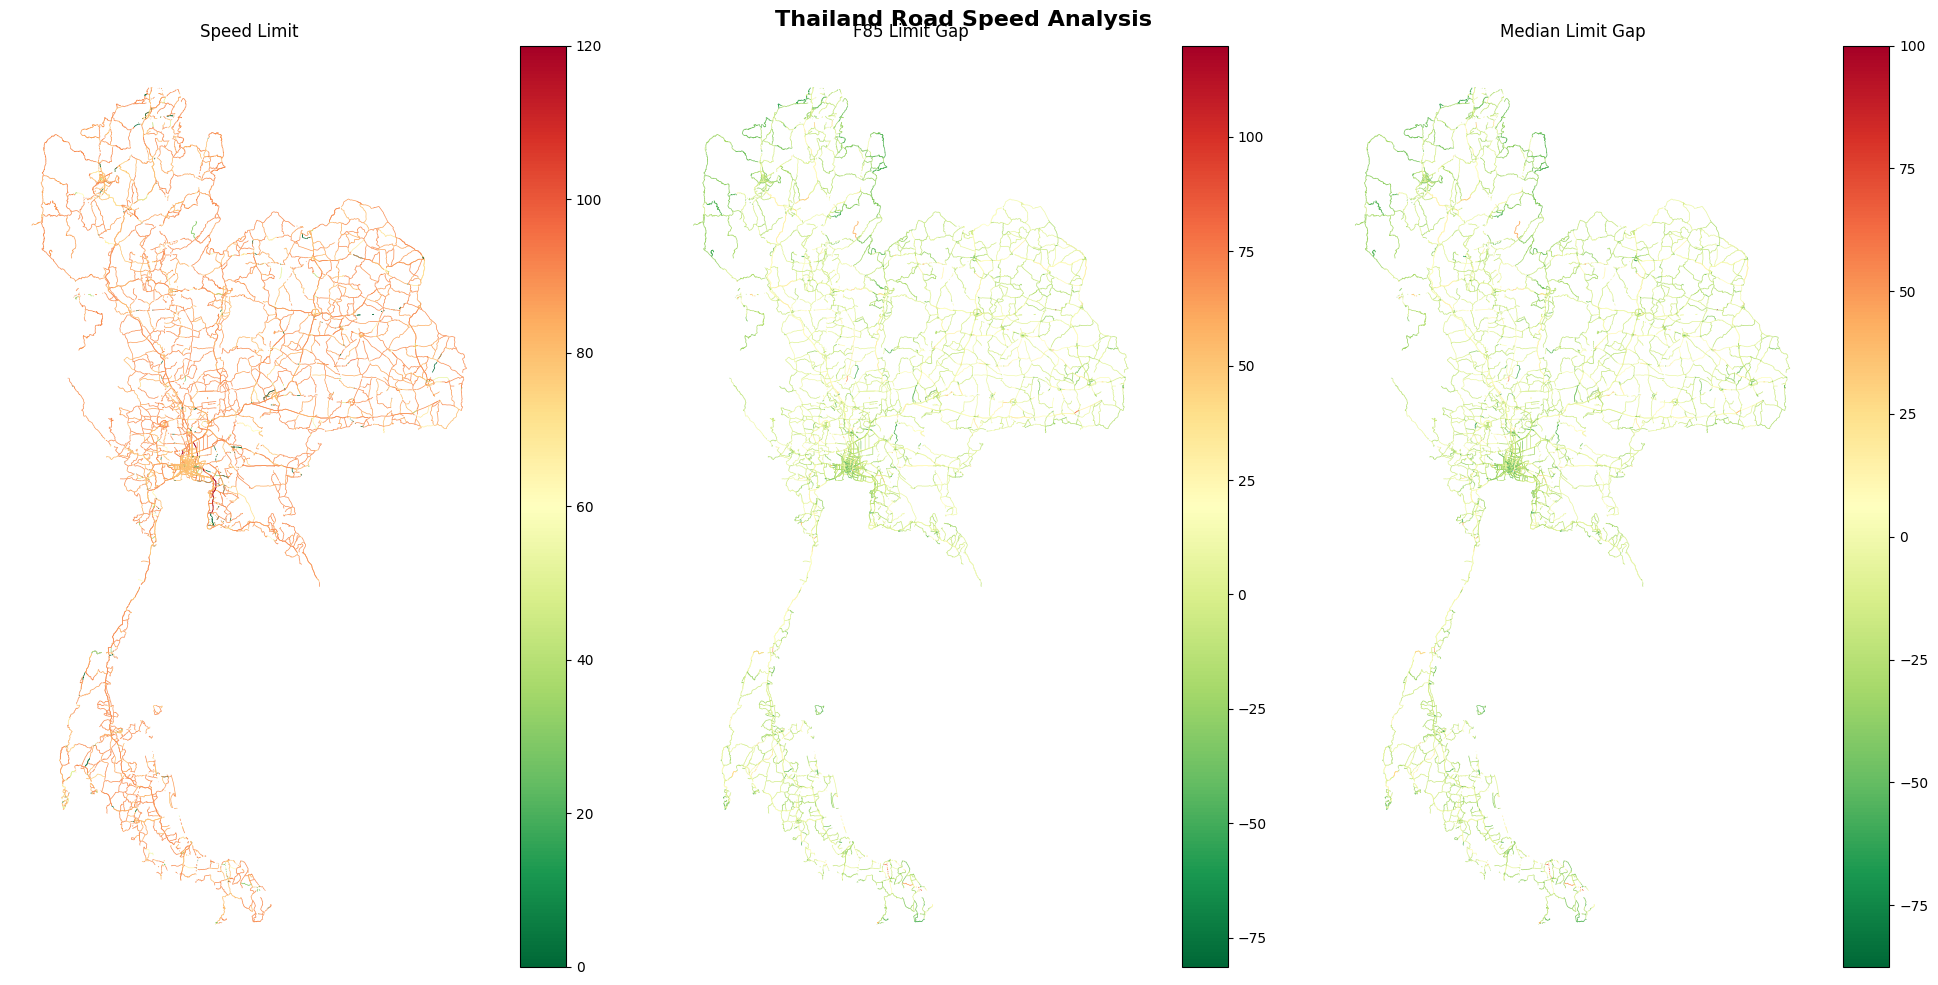

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20,10))

# Plot 1: 
thai_sub_gdf.plot(column='SpeedLimit', ax=axes[0], legend=True, cmap='RdYlGn_r', linewidth=0.5)
axes[0].set_title('Speed Limit')
axes[0].set_axis_off()

# Plot 2: 
thai_sub_gdf.plot(column='f85LimitGap', ax=axes[1], legend=True, cmap='RdYlGn_r', linewidth=0.5)
axes[1].set_title('F85 Limit Gap')
axes[1].set_axis_off()

# Plot 3: 
thai_sub_gdf.plot(column='MedianLimitGap', ax=axes[2], legend=True, cmap='RdYlGn_r', linewidth=0.5)
axes[2].set_title('Median Limit Gap')
axes[2].set_axis_off()

plt.suptitle('Thailand Road Speed Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# Calculate center from the data
bounds = thai_sub_gdf.total_bounds
center_lat = (bounds[1] + bounds[3]) / 2
center_lon = (bounds[0] + bounds[2]) / 2

# Create base map
m = folium.Map(location=[center_lat, center_lon], zoom_start=6, tiles='CartoDB positron')

# Define the 3 layers
layers = [
    ('SpeedLimit', 'Speed Limit (km/h)'),
    ('f85LimitGap', 'F85 Limit Gap (km/h)'),
    ('MedianLimitGap', 'Median Limit Gap (km/h)')
]

for column, legend_name in layers:
    fg = folium.FeatureGroup(name=legend_name, show=(column == 'SpeedLimit'))
    
    for _, row in thai_sub_gdf.iterrows():
        value = row[column]
        
        folium.GeoJson(
            row.geometry,
            style_function=lambda x, val=value: {
                'color': '#d73027' if val > 20 else '#fee08b' if val > 0 else '#1a9850',
                'weight': 3,         # line thickness
                'opacity': 0.8
            },
            tooltip=folium.Tooltip(f"{legend_name}: {value:.1f}")
        ).add_to(fg)
    
    fg.add_to(m)

# Add layer control (top right toggle)
folium.LayerControl(collapsed=False).add_to(m)

#display(m)

In [ ]:
#m.save('thailand_map.html')

## Safe Speed Threshold 

In [16]:
# Safe System thresholds based on World Bank R4L Framework
# Turner et al. (2024), Guide for Safe Speeds, World Bank & WRI
# Format: (RoadClass, LandUse): (min_plausible, safe_threshold, max_plausible)

safe_system = {
    ('motorway', 'RURAL'):    (80,  100, 120),
    ('motorway', 'URBAN'):    (60,   80, 100),
    ('trunk',    'RURAL'):    (60,   80, 100),
    ('trunk',    'URBAN'):    (40,   60,  80),
    ('primary',  'RURAL'):    (50,   80,  90),
    ('primary',  'URBAN'):    (30,   50,  60),
    ('secondary','RURAL'):    (40,   60,  80),
    ('secondary','URBAN'):    (20,   50,  60),
}

In [17]:
# Assign the value to each row based on their roas and land class
# lambda argument: expression 

thai_sub_gdf[['MinPlausible', 'SafeThreshold', 'MaxPlausible']] = thai_sub_gdf.apply(
    lambda row: pd.Series(
        safe_system.get((row['RoadClass'], row['LandUse']), (None, None, None))
    ), axis=1
)

In [18]:
# Add the plausbility flag
thai_sub_gdf['SpeedLimitPlausible'] = (
    (thai_sub_gdf['SpeedLimit'] >= thai_sub_gdf['MinPlausible']) &
    (thai_sub_gdf['SpeedLimit'] <= thai_sub_gdf['MaxPlausible'])
)

In [19]:
# How many segments have implausible speed limits?
print(thai_sub_gdf['SpeedLimitPlausible'].value_counts())

SpeedLimitPlausible
False    6973
True     4161
Name: count, dtype: int64


In [20]:
# What do the implausible ones look like?
display(thai_sub_gdf[~thai_sub_gdf['SpeedLimitPlausible']][['RoadClass', 'LandUse', 'SpeedLimit', 'MinPlausible', 'MaxPlausible']].head(20))

,RoadClass,LandUse,SpeedLimit,MinPlausible,MaxPlausible
5,primary,URBAN,70.0,30,60
6,primary,RURAL,30.0,50,90
17,secondary,URBAN,80.0,20,60
18,secondary,URBAN,80.0,20,60
25,secondary,URBAN,80.0,20,60
26,secondary,URBAN,80.0,20,60
27,secondary,URBAN,80.0,20,60
36,motorway,URBAN,120.0,60,100
38,motorway,URBAN,120.0,60,100
39,motorway,URBAN,120.0,60,100


In [21]:
def classify_plausibility(row):
    if pd.isna(row['SpeedLimit']) or pd.isna(row['MinPlausible']) or pd.isna(row['MaxPlausible']):
        return 'Unknown'
    elif row['SpeedLimit'] < row['MinPlausible']:
        return 'Limit Suspect'
    elif row['SpeedLimit'] > row['MaxPlausible']:
        return 'Limit Too High'
    else:
        return 'Plausible'

thai_sub_gdf['PlausibilityFlag'] = thai_sub_gdf.apply(classify_plausibility, axis=1)

In [22]:
print(thai_sub_gdf['PlausibilityFlag'].value_counts())

display(thai_sub_gdf.groupby(['RoadClass', 'LandUse', 'PlausibilityFlag']).size().reset_index(name='Count'))

PlausibilityFlag
Limit Too High    6876
Plausible         4161
Limit Suspect       97
Name: count, dtype: int64


,RoadClass,LandUse,PlausibilityFlag,Count
0,motorway,RURAL,Limit Suspect,2
1,motorway,RURAL,Plausible,16
2,motorway,URBAN,Limit Suspect,10
3,motorway,URBAN,Limit Too High,22
4,motorway,URBAN,Plausible,79
5,primary,RURAL,Limit Suspect,28
6,primary,RURAL,Limit Too High,3
7,primary,RURAL,Plausible,1346
8,primary,URBAN,Limit Too High,1670
9,primary,URBAN,Plausible,109


In [23]:
# Safe System Exceedance Flags
# Based on World Bank R4L Framework (Turner et al. 2024) 
# and iRAP Thailand Case Study (World Bank 2019)

thai_sub_gdf['F85ExceedsSafeThreshold'] = (
    thai_sub_gdf['F85thPercentileSpeed'] > thai_sub_gdf['SafeThreshold']
)

thai_sub_gdf['MedianExceedsSafeThreshold'] = (
    thai_sub_gdf['MedianSpeed'] > thai_sub_gdf['SafeThreshold']
)

# Summary
print("F85 Exceeds Safe Threshold:")
print(thai_sub_gdf['F85ExceedsSafeThreshold'].value_counts())

print("\nMedian Exceeds Safe Threshold:")
print(thai_sub_gdf['MedianExceedsSafeThreshold'].value_counts())

F85 Exceeds Safe Threshold:
F85ExceedsSafeThreshold
True     9760
False    1374
Name: count, dtype: int64

Median Exceeds Safe Threshold:
MedianExceedsSafeThreshold
True     7729
False    3405
Name: count, dtype: int64


In [24]:
display(thai_sub_gdf.groupby(['RoadClass', 'LandUse'])[['F85ExceedsSafeThreshold', 'MedianExceedsSafeThreshold']].mean().round(3) * 100)

F85ExceedsSafeThreshold  MedianExceedsSafeThreshold
RoadClass LandUse                                                     
motorway  RURAL                       61.1                        11.1
          URBAN                       73.9                        44.1
primary   RURAL                       83.4                        52.7
          URBAN                       93.4                        80.8
secondary RURAL                       86.5                        68.3
          URBAN                       82.9                        65.4
trunk     RURAL                       93.6                        74.7
          URBAN                       96.3                        85.9

In [25]:
# Step 1 — Clip negative gaps to zero (negative = no safety risk)
thai_sub_gdf['F85LimitGapClipped'] = thai_sub_gdf['f85LimitGap'].clip(lower=0)
thai_sub_gdf['MedianLimitGapClipped'] = thai_sub_gdf['MedianLimitGap'].clip(lower=0)
thai_sub_gdf['SpeedSpreadClipped'] = thai_sub_gdf['SpeedSpread'].clip(lower=0)

# Step 2 — Normalize to 0-1 using Min-Max scaling
scaler = MinMaxScaler()

cols_to_normalize = [
    'F85LimitGapClipped',
    'MedianLimitGapClipped', 
    'SpeedSpreadClipped',
    'WeightedSample'
]

normalized = scaler.fit_transform(thai_sub_gdf[cols_to_normalize])

thai_sub_gdf['NormF85LimitGap'] = normalized[:, 0]
thai_sub_gdf['NormMedianLimitGap'] = normalized[:, 1]
thai_sub_gdf['NormSpeedSpread'] = normalized[:, 2]
thai_sub_gdf['NormWeightedSample'] = normalized[:, 3]

In [26]:
thai_sub_gdf.columns

Index(['OBJECTID', 'english_ro', 'OvertureID', 'SampleSize_avg',
       'WeightedSample', 'Percentile', 'SpeedLimit', 'RoadClass',
       'NumberOverLimit', 'MedianSpeed', 'F85thPercentileSpeed', 'ProvinceID',
       'PercentOverLimit', 'RankedPercentile', 'StreetImageLink', 'LandUse',
       'PercentileBand', 'SampleSizeTotal', 'Shape_Length', 'geometry',
       'f85LimitGap', 'MedianLimitGap', 'SpeedSpread', 'MinPlausible',
       'SafeThreshold', 'MaxPlausible', 'SpeedLimitPlausible',
       'PlausibilityFlag', 'F85ExceedsSafeThreshold',
       'MedianExceedsSafeThreshold', 'F85LimitGapClipped',
       'MedianLimitGapClipped', 'SpeedSpreadClipped', 'NormF85LimitGap',
       'NormMedianLimitGap', 'NormSpeedSpread', 'NormWeightedSample'],
      dtype='str')

In [27]:
norm_cols = ['NormF85LimitGap', 'NormMedianLimitGap', 'NormSpeedSpread', 'NormWeightedSample']

print(thai_sub_gdf[norm_cols].describe().round(3))

       NormF85LimitGap  NormMedianLimitGap  NormSpeedSpread  \
count        11134.000           11134.000        11134.000   
mean             0.052               0.015            0.227   
std              0.086               0.058            0.068   
min              0.000               0.000            0.000   
25%              0.000               0.000            0.190   
50%              0.000               0.000            0.227   
75%              0.083               0.000            0.260   
max              1.000               1.000            1.000   

       NormWeightedSample  
count           11134.000  
mean                0.003  
std                 0.026  
min                 0.000  
25%                 0.000  
50%                 0.000  
75%                 0.001  
max                 1.000  


In [29]:


# Log transform WeightedSample first, then normalize
thai_sub_gdf['LogWeightedSample'] = np.log1p(thai_sub_gdf['WeightedSample'])

log_scaler = MinMaxScaler()
thai_sub_gdf['NormWeightedSample'] = log_scaler.fit_transform(
    thai_sub_gdf[['LogWeightedSample']]
)

# Verify the new distribution
print(thai_sub_gdf['NormWeightedSample'].describe().round(3))

count    11134.000
mean         0.601
std          0.096
min          0.000
25%          0.542
50%          0.598
75%          0.657
max          1.000
Name: NormWeightedSample, dtype: float64


In [30]:
# Step 2 — Build the Speed Component
# Weights based on World Bank R4L Framework and iRAP Thailand Case Study
# Boolean flags carry highest weight as they are grounded in cited safety science

w1 = 0.25  # F85ExceedsSafeThreshold
w2 = 0.25  # MedianExceedsSafeThreshold
w3 = 0.20  # NormMedianLimitGap
w4 = 0.15  # NormF85LimitGap
w5 = 0.15  # NormSpeedSpread

thai_sub_gdf['SpeedComponent'] = (
    w1 * thai_sub_gdf['F85ExceedsSafeThreshold'].astype(int) +
    w2 * thai_sub_gdf['MedianExceedsSafeThreshold'].astype(int) +
    w3 * thai_sub_gdf['NormMedianLimitGap'] +
    w4 * thai_sub_gdf['NormF85LimitGap'] +
    w5 * thai_sub_gdf['NormSpeedSpread']
)

# Verify
print(thai_sub_gdf['SpeedComponent'].describe().round(3))

count    11134.000
mean         0.438
std          0.185
min          0.000
25%          0.290
50%          0.534
75%          0.549
max          0.902
Name: SpeedComponent, dtype: float64


In [31]:
# Step 3 — Apply traffic weight
thai_sub_gdf['RawScore'] = (
    thai_sub_gdf['SpeedComponent'] * thai_sub_gdf['NormWeightedSample']
)

# Step 4 — Rescale to 0-100
score_scaler = MinMaxScaler(feature_range=(0, 100))
thai_sub_gdf['SpeedSafetyScore'] = score_scaler.fit_transform(
    thai_sub_gdf[['RawScore']]
)

# Verify
print(thai_sub_gdf['SpeedSafetyScore'].describe().round(2))

count    11134.00
mean        45.39
std         20.94
min          0.00
25%         31.46
50%         51.57
75%         59.43
max        100.00
Name: SpeedSafetyScore, dtype: float64


In [32]:
# Check 1 — Top 20 highest scoring segments
display(thai_sub_gdf.nlargest(20, 'SpeedSafetyScore')[
    ['english_ro', 'RoadClass', 'LandUse', 'SpeedLimit', 
     'F85thPercentileSpeed', 'MedianSpeed', 'SafeThreshold',
     'PlausibilityFlag', 'SpeedSafetyScore']
].reset_index(drop=True))

,english_ro,RoadClass,LandUse,SpeedLimit,F85thPercentileSpeed,MedianSpeed,SafeThreshold,PlausibilityFlag,SpeedSafetyScore
0,Buraphawithi Expressway,motorway,URBAN,80.0,109.947368,92.636842,80,Plausible,100.000000
1,Buraphawithi Expressway,motorway,URBAN,80.0,99.925926,82.612963,80,Plausible,96.388940
2,Chalong Rat Expressway,motorway,URBAN,80.0,108.666667,91.850000,80,Plausible,95.883750
3,Udon Ratthaya Expressway,motorway,URBAN,80.0,115.000000,100.600000,80,Plausible,95.512127
4,Rama II Road,trunk,URBAN,80.0,90.181818,74.750000,60,Plausible,93.717510
5,Phahon Yothin Road,trunk,URBAN,80.0,90.615385,75.092308,60,Plausible,92.021268
6,Chalong Rat Expressway,motorway,URBAN,80.0,107.111111,89.122222,80,Plausible,91.611933
7,Phahonyothin Road,trunk,RURAL,90.0,111.541667,95.868750,80,Plausible,90.960537
8,Phahonyothin Road,trunk,RURAL,90.0,110.583333,94.393750,80,Plausible,90.862100
9,Phetkasem Road,trunk,RURAL,50.0,97.333333,83.966667,80,Limit Suspect,90.310464


In [33]:
# Check 2 — Average score by RoadClass and LandUse
display(thai_sub_gdf.groupby(['RoadClass', 'LandUse'])['SpeedSafetyScore']
    .mean().round(2).reset_index()
    .sort_values('SpeedSafetyScore', ascending=False))

,RoadClass,LandUse,SpeedSafetyScore
7,trunk,URBAN,59.38
6,trunk,RURAL,57.09
3,primary,URBAN,50.05
1,motorway,URBAN,45.79
2,primary,RURAL,41.74
4,secondary,RURAL,41.45
5,secondary,URBAN,39.40
0,motorway,RURAL,31.85


In [34]:
# Check 3 — Average score by PlausibilityFlag
display(thai_sub_gdf.groupby('PlausibilityFlag')['SpeedSafetyScore']
    .mean().round(2))

PlausibilityFlag
Limit Suspect     47.97
Limit Too High    45.50
Plausible         45.16
Name: SpeedSafetyScore, dtype: float64

In [35]:
thai_sub_gdf['PriorityTier'] = pd.cut(
    thai_sub_gdf['SpeedSafetyScore'],
    bins=[0, 25, 50, 75, 100],
    labels=['Low', 'Medium', 'High', 'Critical'],
    include_lowest=True
)

print(thai_sub_gdf['PriorityTier'].value_counts())

PriorityTier
High        5694
Medium      3253
Low         1811
Critical     376
Name: count, dtype: int64


In [37]:
import folium
from folium import GeoJson
import json

# ── 1. MAP CENTRE ──────────────────────────────────────────────────
center_lat = thai_sub_gdf.geometry.centroid.y.mean()
center_lon = thai_sub_gdf.geometry.centroid.x.mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=6, tiles='CartoDB dark_matter')

# ── 2. COLOUR MAPPING FOR PRIORITY TIER ────────────────────────────
tier_colours = {
    'Low': '#2ecc71',       # green
    'Medium': '#f39c12',    # orange  
    'High': '#e74c3c',      # red
    'Critical': '#8e44ad'   # purple
}

def get_colour(tier):
    return tier_colours.get(tier, '#grey')

# ── 3. ADD ROAD SEGMENTS WITH POPUPS ───────────────────────────────
for _, row in thai_sub_gdf.iterrows():
    
    popup_html = f"""
    <div style="font-family: Arial; width: 280px;">
        <h4 style="color: {get_colour(str(row['PriorityTier']))}; margin-bottom: 8px;">
            {row['PriorityTier']} Priority
        </h4>
        <table style="width:100%; font-size:12px;">
            <tr><td><b>Road</b></td><td>{row['english_ro']}</td></tr>
            <tr><td><b>Class</b></td><td>{row['RoadClass']} — {row['LandUse']}</td></tr>
            <tr><td><b>Speed Limit</b></td><td>{row['SpeedLimit']} km/h</td></tr>
            <tr><td><b>F85 Speed</b></td><td>{round(row['F85thPercentileSpeed'], 1)} km/h</td></tr>
            <tr><td><b>Median Speed</b></td><td>{round(row['MedianSpeed'], 1)} km/h</td></tr>
            <tr><td><b>Safe Threshold</b></td><td>{row['SafeThreshold']} km/h</td></tr>
            <tr><td><b>F85 Limit Gap</b></td><td>{round(row['f85LimitGap'], 1)} km/h</td></tr>
            <tr><td><b>Safety Score</b></td><td>{round(row['SpeedSafetyScore'], 1)} / 100</td></tr>
            <tr><td><b>Data Quality</b></td><td>{row['PlausibilityFlag']}</td></tr>
        </table>
    </div>
    """
    
    folium.GeoJson(
        row['geometry'],
        style_function=lambda feature, tier=str(row['PriorityTier']): {
            'color': get_colour(tier),
            'weight': 2,
            'opacity': 0.8
        },
        popup=folium.Popup(popup_html, max_width=300)
    ).add_to(m)

# ── 4. LEGEND ──────────────────────────────────────────────────────
legend_html = """
<div style="position: fixed; bottom: 40px; left: 40px; z-index: 1000;
            background-color: white; padding: 15px; border-radius: 8px;
            box-shadow: 2px 2px 6px rgba(0,0,0,0.3); font-family: Arial;">
    <b style="font-size:14px;">Speed Safety Score</b><br><br>
    <span style="color:#8e44ad;">&#9646;</span> Critical (75–100)<br>
    <span style="color:#e74c3c;">&#9646;</span> High (50–75)<br>
    <span style="color:#f39c12;">&#9646;</span> Medium (25–50)<br>
    <span style="color:#2ecc71;">&#9646;</span> Low (0–25)<br>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

#m

/var/folders/p1/qndb646d5b7602s3htcc6gvh0000gn/T/ipykernel_56919/2781167448.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lat = thai_sub_gdf.geometry.centroid.y.mean()
/var/folders/p1/qndb646d5b7602s3htcc6gvh0000gn/T/ipykernel_56919/2781167448.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lon = thai_sub_gdf.geometry.centroid.x.mean()


In [38]:
m.save('thailand_speed_safety_map.html')
print("Map saved!")

Map saved!
